In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
def preprocess(df):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
    df.dropna(subset=["FTHG", "FTAG", "FTR"], inplace=True)
    df["FTHG"] = df["FTHG"].astype(int)
    df["FTAG"] = df["FTAG"].astype(int)
    return df

In [17]:
seasons=["1415","1516","1617","1718","1819","1920","2021","2122","2223","2324"]
league="E0"
dfs={}
for season in seasons:
    url=f"https://www.football-data.co.uk/mmz4281/{season}/{league}.csv"
    dfs[season]=pd.read_csv(url,encoding='latin-1')

In [18]:
cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]

for season in dfs:
    dfs[season]=dfs[season][cols]

In [31]:
for season in dfs:
    dfs[season]=preprocess(dfs[season])

In [32]:
for season in seasons:
    print(f"Average Home Goal in {season} season: {dfs[f'{season}']['FTHG'].mean()}")
    print(f"Average Away Goal in {season} season: {dfs[f'{season}']['FTAG'].mean()}\n")
    

Average Home Goal in 1415 season: 1.4736842105263157
Average Away Goal in 1415 season: 1.0921052631578947

Average Home Goal in 1516 season: 1.4921052631578948
Average Away Goal in 1516 season: 1.2078947368421054

Average Home Goal in 1617 season: 1.5973684210526315
Average Away Goal in 1617 season: 1.2026315789473685

Average Home Goal in 1718 season: 1.5315789473684212
Average Away Goal in 1718 season: 1.1473684210526316

Average Home Goal in 1819 season: 1.568421052631579
Average Away Goal in 1819 season: 1.2526315789473683

Average Home Goal in 1920 season: 1.5157894736842106
Average Away Goal in 1920 season: 1.2052631578947368

Average Home Goal in 2021 season: 1.3526315789473684
Average Away Goal in 2021 season: 1.3421052631578947

Average Home Goal in 2122 season: 1.513157894736842
Average Away Goal in 2122 season: 1.305263157894737

Average Home Goal in 2223 season: 1.6342105263157896
Average Away Goal in 2223 season: 1.2184210526315788

Average Home Goal in 2324 season: 1.8
Av

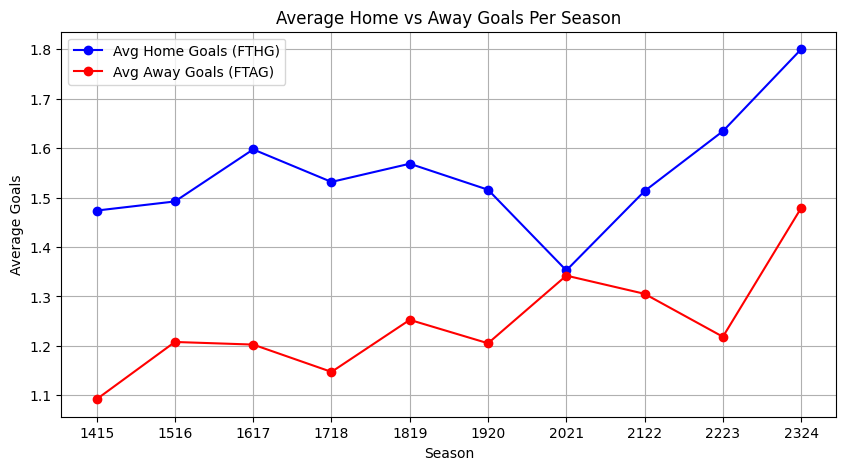

In [33]:
seasons = list(dfs.keys())
avg_fthg = [dfs[s]["FTHG"].mean() for s in seasons]
avg_ftag = [dfs[s]["FTAG"].mean() for s in seasons]

plt.figure(figsize=(10, 5))
plt.plot(seasons, avg_fthg, color="blue", marker="o", label="Avg Home Goals (FTHG)")
plt.plot(seasons, avg_ftag, color="red", marker="o", label="Avg Away Goals (FTAG)")

plt.title("Average Home vs Away Goals Per Season")
plt.xlabel("Season")
plt.ylabel("Average Goals")
plt.legend()
plt.grid(True)
plt.show()